In [7]:
# %load_ext autoreload
%autoreload 2
from scripts.ingestion import *
from scripts.data_qc import *
from scripts.poke_detection import *


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

In [6]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/linearity_test_ch5"

session_index = build_sessions_index(data_dir)

In [3]:
# extract the z-axis displacements
dzs = session_index["notes"].to_list()
dzs = [re.search(r"dz=(\d+)", note).group(1) for note in dzs]
dz_all = [int(dz) for dz in dzs]
dz_all = np.array(dz_all)
dz_all.sort()

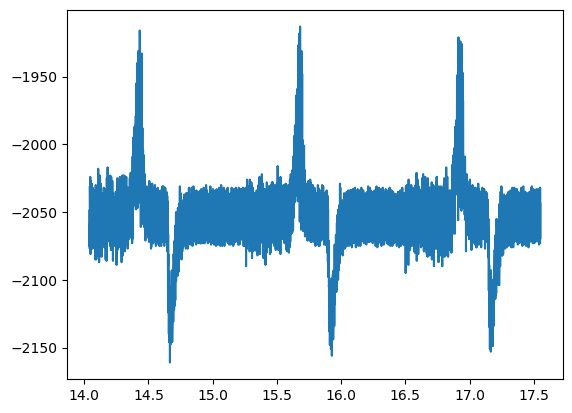

In [11]:
# check sign of the signal
dz = 260

query = pl.col("notes").str.contains(f"dz={dz}")

filtered = session_index.filter(query).to_dicts()[0]
fs = filtered["fs_hz"]
N_cap = filtered["saved_sweeps"]

pdf = load_session_pandas(filtered, flip=True)
s0, s1 = 20000, 25000
t0, t1 = s0 / fs, s1 / fs
times = np.linspace(t0, t1, len(pdf["CH5"][s0:s1]))
plt.plot(times, pdf["CH5"][s0:s1])

In [15]:
min_height = 40 if (dz < 150) else 50
n_discard, pdf_trim, mixed_pos, final_peaks = poke_detection(pdf, fs, N_cap, height=min_height, min_sep_ms=500, CHS=["CH5"])

poke_windows = extract_poke_windows(pdf_trim, final_peaks, fs, pre_ms=250.0, post_ms=100.0)
force_peaks, F = force_peak_detection(pdf_trim, fs, height=1500, min_sep_ms=500)
print(f"dz={dz}, detected {len(final_peaks)} pokes, force peaks: {len(force_peaks)}")

# features = extract_sensor_peak_strength_session(poke_windows, fs, t_ref_ms=50.0, pre_ms=50.0, post_ms=100.0)

# peak_fs = extract_force_peak_strength(pdf_trim, force_peaks, fs, pre_ms=250, post_ms=250, quant=0.98)

dz=260, detected 10 pokes, force peaks: 10


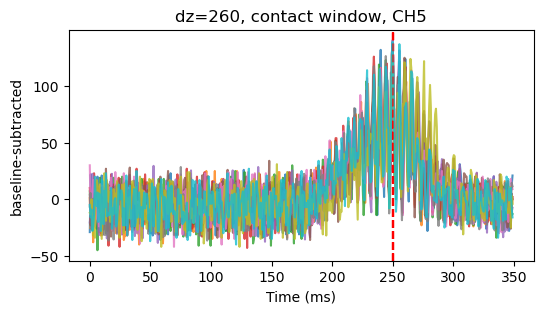

Text(0.5, 1.0, 'Contact window, CH5')

In [16]:
f = plot_poke_windows(poke_windows, fs, ch="CH5", n=len(poke_windows),
                      title=f"dz={dz}, contact window, CH5")
ax = f.axes[0]
ax.set_title("Contact window, CH5")